# Word Cloud using CSV (Ko)

Data: Movie Reviews (`./data/movie_reviews_ko.csv`)

### 1. Load Data

In [16]:
import pandas as pd

df = pd.read_csv('./data/movie_reviews_ko.txt', sep='\t')
df.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [17]:
df.shape

(150000, 3)

In [18]:
df['label'].value_counts() #.to_frame()

label
0    75173
1    74827
Name: count, dtype: int64

### 2. Text Preprocessing

In [37]:
from konlpy.tag import Okt
from wordcloud import WordCloud
from matplotlib import pyplot as plt


def get_preprocessed_corpus(text, stopwords=None):

    okt = Okt()
    tagged = okt.pos(text, stem=True, norm=True)
    filtered = [w for w, pos in tagged if pos[0] in 'N']
    filtered = [w for w in filtered if len(w) > 1]
    
    if stopwords is not None:
        filtered = [w for w in filtered if w not in stopwords]

    return ' '.join(filtered)


def draw_wordcloud(text, title=None):
    wordcloud = WordCloud(font_path='./NanumSquareRoundR.ttf', 
                          width=800, height=400, background_color='white').generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

In [38]:
custom_stopwords = ['영화', '이 영화', '이영화', '진짜', '정말', '보고',]
df['processed_review'] = df['document'].apply(lambda x: get_preprocessed_corpus(x, stopwords=custom_stopwords))

### 3. Draw Wordclouds

#### 3-1. All reviews

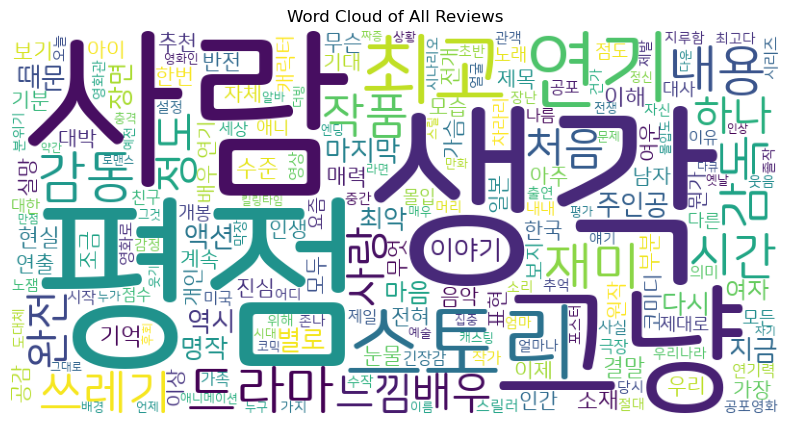

In [39]:
text_all = ' '.join(df['processed_review'])

draw_wordcloud(text_all, title='Word Cloud of All Reviews')

#### 3-2. Positive/Negative Reviews


In [40]:
pos_reviews = df.loc[df['label']==1, 'processed_review']
neg_reviews = df.loc[df['label']==0, 'processed_review']

print('Number of positive reviews:', len(pos_reviews))
print('Number of negative reviews:', len(neg_reviews))

Number of positive reviews: 74827
Number of negative reviews: 75173


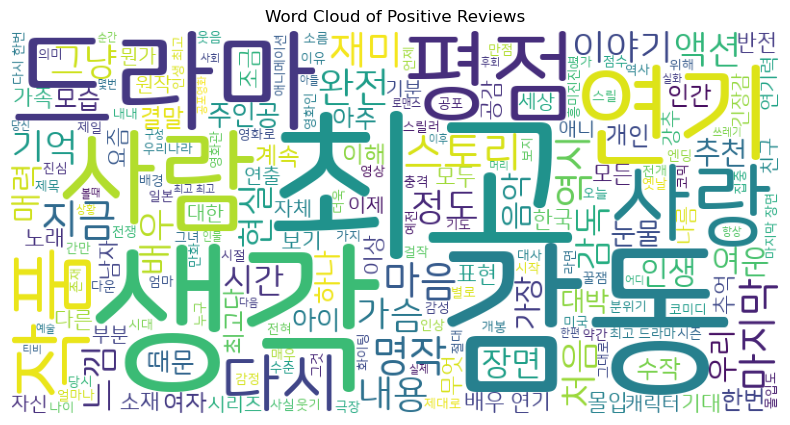

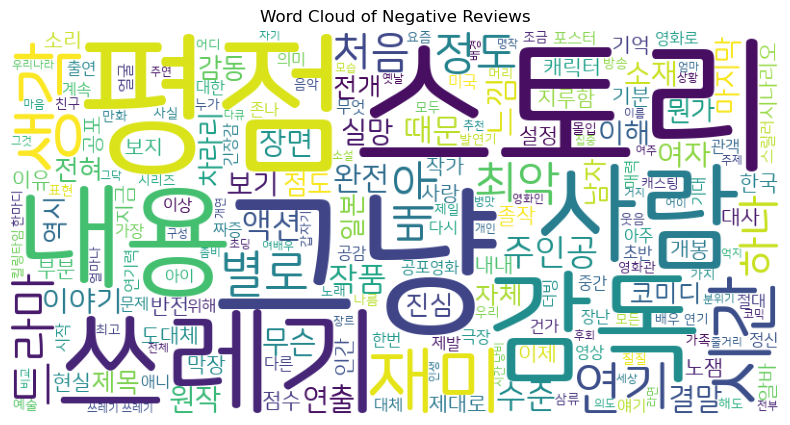

In [41]:
text_pos = ' '.join(pos_reviews)
draw_wordcloud(text_pos, title='Word Cloud of Positive Reviews')

text_neg = ' '.join(neg_reviews)
draw_wordcloud(text_neg, title='Word Cloud of Negative Reviews')

#### Drill-down: Let's try to understand the context of keywords!

In [43]:
# Q. Find and display some negative reviews that contain the word "good"
df.loc[(df['label']==0) & (df['processed_review'].str.contains('그냥')), :]

,id,document,label,processed_review
53,7865630,"난또 저 꼬마애가 무슨 원한이 깊길래.,. 했더니 OO 그냥 혼자 나대다 OO걸 어...",0,난또 꼬마 애가 무슨 원한 그냥 혼자
121,8902582,그냥 불법체류자 때려잡는 영화면 좋았을텐데...무슨 우상화를 만든다고 미국의 따뜻한...,0,그냥 불법체류자 무슨 우상화 미국 설정 뭐임
182,6555618,별점 주기도 아깝네요 얼마나 내용이 진부한지 욕 밖에 안나오네요보고 재밌다고 하는 ...,0,주기도 얼마나 내용 사람 초딩 화가 아무 보지 그냥 티비
283,7862272,전미 박스 오피스1위 ㅋㅋ 그냥 몰아주기 하는건가 어떻게 이런영화가 1위를 하지 옛...,0,박스 오피스 그냥 건가 옛날 80~90년 우뢰매 수준 물폭탄 싸움 물폭탄
391,8313164,"스토리, 액션, 그래픽 머 하나 건질게 없는 망작. 그냥 게임으로나 즐기셔~",0,스토리 액션 그래픽 하나 망작 그냥 게임
...,...,...,...,...
149486,8399298,그냥 심심할 때나 잠깐 볼만한 영화. 그나마 칭찬할 점은 이런 생각을 해내기도 쉽지...,0,그냥 잠깐 칭찬 생각
149770,7951475,스케이트보드만으로는 안 되겠던지 온갖 진부한 것들을 어설프게 섞었다. 인물의 행동은...,0,스케이트보드 온갖 인물 행동 그냥 가끔 슬로우 모션 장면
149790,9643499,보다가맘 ㄴ잼이라서 ㅋㅋ 이선균 나와서봣음 ㅋㅋ 근데님들도 보다말듯 영화가 그냥 레...,0,이선균 봣음 데님 그냥 레알 재미
149923,7343497,"만들기 싫은데 어거지로 만든 영화 ㅋㅋ 돈날리면서 왜 이렇게 굳이,., 그냥 개인 ...",0,만들기 어거지 굳이 그냥 개인


In [45]:
df.loc[53].document

'난또 저 꼬마애가 무슨 원한이 깊길래.,. 했더니 OO 그냥 혼자 나대다 OO걸 어쩌라고.'

In [46]:
df.loc[53].processed_review

'난또 꼬마 애가 무슨 원한 그냥 혼자'